# Finding Outliers in PCA Plot

This notebook loads the PCA results and identifies outliers based on distance from the center of the PCA space.

In [3]:
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os

In [4]:
# Specify path to PCA output
os.chdir(Path.cwd().parent)
pca_output_root = Path("analysis/temporaryPCA1000Files") # CHANGE THIS TO PATH TO PCA OUTPUT

print(f"Files found: at {pca_output_root}:")
for f in pca_output_root.glob("*"):
    print(f"-{f.name}")

Files found: at analysis/temporaryPCA1000Files:


In [3]:
# Load PCA data
pca_data = np.load(pca_output_root / "pca_results.npz", allow_pickle=True)
X_pca = pca_data["X_pca"]
X_raw = pca_data["X_raw"] # raw data
evr = pca_data["evr"] # explained variance ratio

print(f"X_pca shape: {X_pca.shape}") # should have shape (n_samples, n_components)
print(f"X_raw shape: {X_raw.shape}") # should have shape (n_samples, n_mels)

X_pca shape: (53000, 20)
X_raw shape: (53000, 104)


In [4]:
# Load window metadata
window_data = np.load(pca_output_root / "window_index.npz", allow_pickle=True)
files = window_data["files"]
start_frames = window_data["start_frames"]
start_secs = window_data["start_secs"]

print(f"{len(files)} windows")
print(f"for example: {files[:5]}")

53000 windows
for example: ['6229.220802140000.npz' '6229.220802140000.npz' '6229.220802140000.npz'
 '6229.220802140000.npz' '6229.220802140000.npz']


In [ ]:
# Load metadata
with open(pca_output_root / "pca_meta.json") as f:
    meta = json.load(f)

print(f"PCA analysis metadata:")
print(f"  Created: {meta['created']}")
print(f"  Total windows: {meta['n_windows']}")
print(f"  n Components: {meta['n_components']}")
print(f"  Files in root: {len(meta['files'])}")

cov_matrix = np.cov(X_pca, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)
distances_mahalanobis = np.array([np.sqrt((x - mean_pca).T @ inv_cov_matrix @ (x - mean_pca)) for x in X_pca])

PCA analysis metadata:
  Created: 2026-03-13T12:15:00.048506
  Total windows: 53000
  n Components: 20
  Files in root: 1000


In [22]:
# Calculate distance from center in PCA space
# Alternatively try using Mahalanobis afstand

# Euclidean distance from mean
mean_pca = X_pca.mean(axis=0)
distances_euclidean = np.sqrt(np.sum((X_pca - mean_pca) ** 2, axis=1))

# Mahalanobis distance from mean
cov_pca = np.cov(X_pca, rowvar=False) # rowvar to correct for samples in rows
inv_cov = np.linalg.inv(cov_pca)


distances_mahal = [np.sqrt((X_pca[i] - mean_pca).T @ inv_cov @ (X_pca[i] - mean_pca)) for i in range(X_pca.shape[0])]
distances_mahal = np.array(distances_mahal)


print(f"Euclidean distance stats:")
print(f"  Mean: {distances_euclidean.mean():.3f}, Std: {distances_euclidean.std():.3f}")
print(f"  Min: {distances_euclidean.min():.3f}, Max: {distances_euclidean.max():.3f}")
print(f"\nMahalanobis distance stats:")
print(f"  Mean: {distances_mahal.mean():.3f}, Std: {distances_mahal.std():.3f}")
print(f"  Min: {distances_mahal.min():.3f}, Max: {distances_mahal.max():.3f}")

Euclidean distance stats:
  Mean: 30.464, Std: 26.815
  Min: 1.979, Max: 313.427

Mahalanobis distance stats:
  Mean: 4.094, Std: 1.799
  Min: 1.369, Max: 44.476


In [7]:
# Define outliers and make mask
distances = distances_euclidean
threshold = distances.mean() + 3 * distances.std() # outlier defined as more than 3 std dev from mean
outlier_mask = distances > threshold
outlier_indices = np.where(outlier_mask)[0]

print(f"Threshold: {threshold:.3f}")
print(f"Number of outliers: {len(outlier_indices)} out of {len(distances)} windows")

Threshold: 110.908
Number of outliers: 528 out of 53000 windows


In [13]:
# Create detailed table of outliers with source information
outlier_info = []

for idx in outlier_indices:
    outlier_info.append({
        "Index": idx,
        "File": files[idx],
        "Start Frame": int(start_frames[idx]),
        "Start Time (s)": float(start_secs[idx]),
        "Distance": distances[idx],
        "PC1": X_pca[idx, 0],
        "PC2": X_pca[idx, 1] if X_pca.shape[1] > 1 else 0,
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df = outlier_df.sort_values("Distance", ascending=False)

print(outlier_df.to_string())

     Index                   File  Start Frame  Start Time (s)    Distance         PC1        PC2
52      52  6229.220802140000.npz        32500           260.0  313.427185 -291.796509 -45.385639
451    582  6229.220802172000.npz        32500           260.0  306.801697 -286.765594 -44.352394
105    105  6229.220802142000.npz        32500           260.0  297.315399 -283.905548 -38.057724
158    158  6229.220802144000.npz        32500           260.0  279.461578 -273.550720 -32.924660
237    237  6229.220802152000.npz        15625           125.0  269.827637 -268.619659 -15.076997
212    212  6229.220802152000.npz            0             0.0  269.388214 -268.154785 -15.424603
253    253  6229.220802152000.npz        25625           205.0  269.379547 -268.198792 -15.133900
89      89  6229.220802142000.npz        22500           180.0  269.286469 -268.069092 -15.498666
238    238  6229.220802152000.npz        16250           130.0  269.260620 -268.038605 -15.022441
91      91  6229.220

In [14]:
# Group outliers by source file
outliers_by_file_grouped = outlier_df.groupby("File").size().sort_values(ascending=False)
outliers_by_file = outlier_df.sort_values("File", ascending=False)
print(outliers_by_file_grouped.to_string())
print(outliers_by_file.to_string())

File
6229.220802140000.npz    53
6229.220802172000.npz    53
6229.220802144000.npz    53
6229.220802150000.npz    53
6229.220802152000.npz    53
6229.220802142000.npz    53
6229.220802170000.npz    53
6229.220802154000.npz    51
6229.220802174000.npz    50
6229.220802160000.npz    30
6229.220816204000.npz     9
6229.220818034000.npz     6
6229.220817040000.npz     4
6229.220808174000.npz     2
6229.220809202000.npz     2
6229.220824170000.npz     1
6229.220827012000.npz     1
6229.220827114000.npz     1
     Index                   File  Start Frame  Start Time (s)    Distance         PC1        PC2
527  45260  6229.220827114000.npz        31875           255.0  112.919952   96.516991 -35.428734
526  44288  6229.220827012000.npz        20625           165.0  120.649529  113.734116 -33.804310
525  39802  6229.220824170000.npz        32500           260.0  111.687027  -50.053780 -22.608366
522  28660  6229.220818034000.npz        25000           200.0  120.636482  119.896400  -9.331877
5

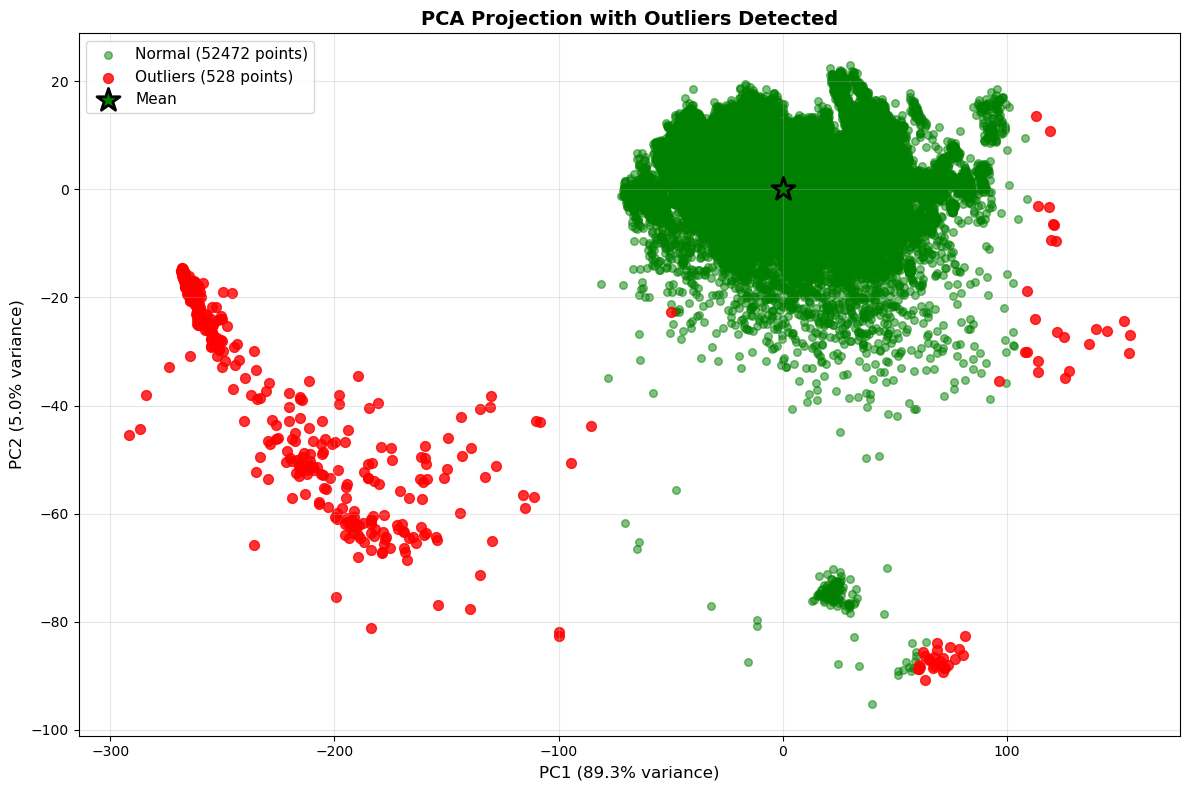


Plot saved to: analysis/temporaryPCA1000Files/outliers_pca_plot.png


In [ ]:
# Visualize PCA plot with outliers highlighted
assert X_pca.shape[1] >= 2, "minimum 2 PCA components for plotting"
fig, ax = plt.subplots(figsize=(12, 8))

# Plot normal points
normal_mask = ~outlier_mask
normal_x = X_pca[normal_mask, 0]
normal_y = X_pca[normal_mask, 1]
ax.scatter(normal_x, normal_y, 
            c='green', alpha=0.5, s=30, label=f'Normal ({normal_mask.sum()} points)')

# Plot outliers
outlier_x = X_pca[outlier_mask, 0]
outlier_y = X_pca[outlier_mask, 1]
ax.scatter(outlier_x, outlier_y, 
            c='red', alpha=0.8, s=50, label=f'Outliers ({outlier_mask.sum()} points)')

# Plot center
ax.scatter(mean_pca[0], mean_pca[1], c='green', s=300, 
            marker='*', label='Mean', zorder=5, edgecolors='black', linewidths=2)

ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Projection with Outliers Detected', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#out_plot = pca_output_root / "outliers_pca_plot.png"
#plt.savefig(out_plot, dpi=150, bbox_inches='tight')
plt.show()

#print(f"\nPlot saved to: {out_plot}")


In [11]:
# Save outlier summary to CSV
csv_path = pca_output_root / "outliers_summary.csv"
outlier_df.to_csv(csv_path, index=False)
print(f"Outlier summary saved to: {csv_path}")
print(f"\nTotal outliers extracted: {len(outlier_df)}")

Outlier summary saved to: analysis/pca_output/testrun/outliers_summary.csv

Total outliers extracted: 2
